## Consumer Sentiment vs Consumer Consumption

### Preparation
---

#### Import statements

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates



pd.options.display.float_format ="{:,.2f}".format

#### Load the Datasets

In [44]:
consumer_sentiment_df = pd.read_csv("./Datasets/UMCSENT.csv")
consumer_economic_conditions_df= pd.read_excel("./Datasets/Current_Economic_Conditions.xlsx")
consumer_expectations_df= pd.read_excel("./Datasets/Consumer_Expectations.xlsx")
real_consumption_expenditures_annual= pd.read_csv("./Datasets/Real_Personal_Consumption_not_adjsuted.csv")


### Initial checks
---

Use of the data is from 2000 onwards - so go to excel and remove the earlier values for ease.

<section class="data-checks">

  <h5>First Set of Checks</h5>
  <ul>
    <li>Head</li>
    <li>Tail</li>
    <li>Datatypes</li>
    <li>Columns</li>
    <li>Shape</li>
  </ul>

  <h5>Second Set of Checks</h5>
  <ul>
    <li>Remove unused columns</li>
    <li>Check duplicate values</li>
    <li>Missing values</li>
  </ul>
</section>


#### Consumer sentiment checks

In [45]:
#### first set of checks
consumer_sentiment_df.sample(5)         # Date is not the index - np
consumer_sentiment_df.head()            # Starts at the correct date
consumer_sentiment_df.tail()            # ends at 2026-01
consumer_sentiment_df.columns           # No spaces which is good but do need to rename  + No need to drop columns
consumer_sentiment_df.dtypes            # Observation date needs to be converted

    #### Initial adjustments
consumer_sentiment_df.rename(columns={"observation_date":"Date","UMCSENT":"Sentiment_index"}, inplace=True)     # Fixed the index
consumer_sentiment_df["Date"]= pd.to_datetime(consumer_sentiment_df["Date"], format ="%d/%m/%Y")               # Datetime conversion but it is alsop in daily format so convert to thrifst of the mont



#### Second set of checks
consumer_sentiment_df.columns           #No need to drop columns
consumer_sentiment_df.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
consumer_sentiment_df.isna().sum()                                              # No missing values for any of the dates + Need to check if all the 12 months are there in the dataset

        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="MS").difference(consumer_sentiment_df["Date"]))
                    # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
                    ## There are no missing values

consumer_sentiment_df

DatetimeIndex([], dtype='datetime64[us]', freq='MS')


,Date,Sentiment_index
0,2000-01-01,112.00
1,2000-02-01,111.30
2,2000-03-01,107.10
3,2000-04-01,109.20
4,2000-05-01,110.70
...,...,...
308,2025-09-01,55.10
309,2025-10-01,53.60
310,2025-11-01,51.00
311,2025-12-01,52.90


#### Consumer Expectations checks

In [46]:
#### first set of checks
consumer_expectations_df.sample(5)
consumer_expectations_df.head(30)       # Starts at the correct date
consumer_expectations_df.tail()         # ends at 2026-01
consumer_expectations_df.dtypes          # Observation no need to be converted since its a datetime.
consumer_expectations_df.columns        # No spaces which is good but do need to rename  + No need to drop columns

    #### Initial adjustments
consumer_expectations_df.rename(columns={"Datemy":"Date","ICE":"Consumer_Expectations_index"}, inplace=True)     # Fixed the index

#### Second set of checks
consumer_expectations_df.columns           #Need to remove the recessions column

consumer_expectations_df.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
consumer_expectations_df.isna().sum()                                              # No missing values for any of the dates + Need to check if all the 12 months are there in the dataset

        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="MS").difference(consumer_expectations_df["Date"]))
                    # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
                    # There are no missing values( from geeks for geeeks)

    #### Adjustments
consumer_expectations_df.drop(columns=["RECESSION"], inplace=True)          ## Remove the recession column
consumer_expectations_df["Date"]= pd.to_datetime(consumer_expectations_df["Date"])
consumer_expectations_df


DatetimeIndex([], dtype='datetime64[us]', freq='MS')


,Date,Consumer_Expectations_index
0,2000-01-01,103.60
1,2000-02-01,105.80
2,2000-03-01,106.00
3,2000-04-01,104.40
4,2000-05-01,103.40
...,...,...
309,2025-10-01,52.60
310,2025-11-01,51.00
311,2025-12-01,52.00
312,2026-01-01,54.20


#### Consumer Economic Conditions checks

In [47]:
#### first set of checks
consumer_economic_conditions_df.sample(5)         # Date is not the index - np
consumer_economic_conditions_df.head()            # Starts at the correct date
consumer_economic_conditions_df.tail()            # ends at 2026-02
consumer_economic_conditions_df.columns           # No spaces which is good but do need to rename  + No need to drop columns
consumer_economic_conditions_df.dtypes            # Npo changes needed

    #### Initial adjustments
consumer_economic_conditions_df.rename(columns={"Unnamed: 0":"Date","3mma":"Economic_Conditions_index"}, inplace=True)     # Fixed the index


#### Second set of checks
consumer_economic_conditions_df.columns           #Need to drop the recessions column
consumer_economic_conditions_df.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
consumer_economic_conditions_df.isna().sum()                                              # No missing values for any of the dates+ missing for recession + Need to check if all the 12 months are there

    # Adjustments
consumer_economic_conditions_df.drop(columns=["Recession"], inplace=True)       # Remove the Recession column
consumer_economic_conditions_df["Date"]= pd.to_datetime(consumer_economic_conditions_df["Date"])



        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="MS").difference(consumer_economic_conditions_df["Date"]))
                    # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
                    ## There are no missing values
consumer_economic_conditions_df

DatetimeIndex([], dtype='datetime64[us]', freq='MS')


,Date,Economic_Conditions_index
0,2000-01-01,115.40
1,2000-02-01,115.40
2,2000-03-01,116.50
3,2000-04-01,116.70
4,2000-05-01,117.70
...,...,...
309,2025-10-01,60.20
310,2025-11-01,56.70
311,2025-12-01,53.40
312,2026-01-01,52.30


#### Real Consumption Expenditures

In [58]:
#### first set of checks
real_consumption_expenditures_annual.sample(5)         # Date is not the index - np
real_consumption_expenditures_annual.head()            # Starts at the correct date
real_consumption_expenditures_annual.tail()            # ends at 2025-01
real_consumption_expenditures_annual.columns           # No spaces which is good but do need to rename  + No need to drop columns
real_consumption_expenditures_annual.dtypes                           # Observation date needs to be converted

    #### Initial adjustments
real_consumption_expenditures_annual.rename(columns={"observation_date":"Date","PCECCA":"Consumption_Expenditures( Billions)"}, inplace=True)     # Fixed the index
real_consumption_expenditures_annual["Date"]= pd.to_datetime(real_consumption_expenditures_annual["Date"], format ="%d/%m/%Y")               # Datetime conversion but it is alsop in daily format so convert to thrifst of the mont
real_consumption_expenditures_annual


#### Second set of checks
real_consumption_expenditures_annual.columns           #No need to drop columns
real_consumption_expenditures_annual.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
real_consumption_expenditures_annual.isna().sum()                                              # No missing values for any of the dates + Need to check if all the 12 months are there in the dataset

        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="YS").difference(consumer_sentiment_df["Date"]))      ## This is yearly so from year start.
#                     # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
#                     ## There are no missing values
#
real_consumption_expenditures_annual

DatetimeIndex([], dtype='datetime64[us]', freq='YS-JAN')


,Date,Consumption_Expenditures( Billions)
0,2000-01-01,"9,166.88"
1,2001-01-01,"9,393.89"
2,2002-01-01,"9,632.77"
3,2003-01-01,"9,937.57"
4,2004-01-01,"10,312.21"
5,2005-01-01,"10,677.41"
6,2006-01-01,"10,986.77"
7,2007-01-01,"11,253.85"
8,2008-01-01,"11,270.74"
9,2009-01-01,"11,123.60"


### Merge all (Sentiment) Indicators
---

In [49]:
initial_df = pd.merge(consumer_economic_conditions_df, consumer_expectations_df, on="Date", how="inner")
clean_df= pd.merge(initial_df,consumer_sentiment_df, on="Date", how="outer")
clean_df.head(20)

,Date,Economic_Conditions_index,Consumer_Expectations_index,Sentiment_index
0,2000-01-01,115.40,103.60,112.00
1,2000-02-01,115.40,105.80,111.30
2,2000-03-01,116.50,106.00,107.10
3,2000-04-01,116.70,104.40,109.20
4,2000-05-01,117.70,103.40,110.70
5,2000-06-01,117.60,103.10,106.40
6,2000-07-01,116.40,103.40,108.30
7,2000-08-01,113.90,103.10,107.30
8,2000-09-01,112.90,104.00,106.80
9,2000-10-01,112.70,102.70,105.80


### Descriptive statistics
---

In [50]:
clean_df.describe()

,Date,Economic_Conditions_index,Consumer_Expectations_index,Sentiment_index
count,314,314.00,314.00,313.00
mean,2013-01-15 04:03:03.439490,92.22,75.26,81.81
min,2000-01-01 00:00:00,52.30,49.30,50.00
25%,2006-07-08 18:00:00,78.95,67.10,71.50
50%,2013-01-16 12:00:00,96.25,75.20,82.90
75%,2019-07-24 06:00:00,106.60,84.95,93.00
max,2026-02-01 00:00:00,117.70,106.00,112.00
std,NaN,17.04,12.30,13.97


### Visualisation
---

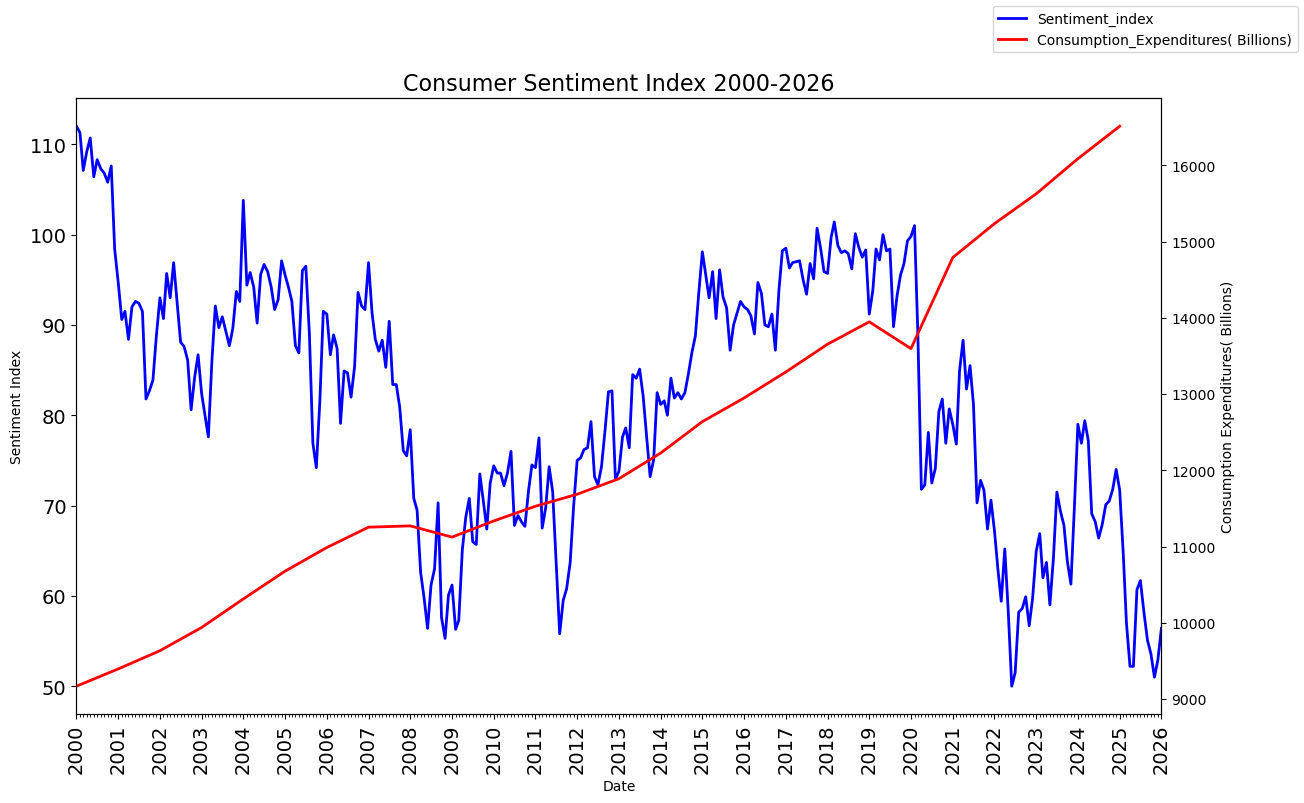

In [70]:
## Plot
    ## Initial features
plt.figure(figsize=(14,8))
plt.xticks(fontsize=14, rotation = 90)
plt.yticks(fontsize=14)

ax1 = plt.gca()
ax2 = ax1.twinx()
    ## Plots
ax1.plot(clean_df["Date"],
         clean_df["Sentiment_index"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")

ax2.plot(real_consumption_expenditures_annual["Date"],
         real_consumption_expenditures_annual["Consumption_Expenditures( Billions)"],
         color="Red",
         linewidth=2,
         label="Consumption_Expenditures( Billions)")

    ## Adding in the date functionalities
Year = mdates.YearLocator()
Months = mdates.MonthLocator()
Years_FMT = mdates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(Year)
ax1.xaxis.set_minor_locator(Months)
ax1.xaxis.set_major_formatter(Years_FMT)


    ## Final features

ax1.set_xlabel("Date")
ax1.set_ylabel("Sentiment Index")
ax2.set_ylabel("Consumption Expenditures( Billions)")
plt.title("Consumer Sentiment Index 2000-2026", fontsize=16)
plt.xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2026-01-01"))
fig = plt.gcf()
fig.legend()
plt.show()

C:\Users\mathe\AppData\Local\Temp\ipykernel_788\2942724166.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


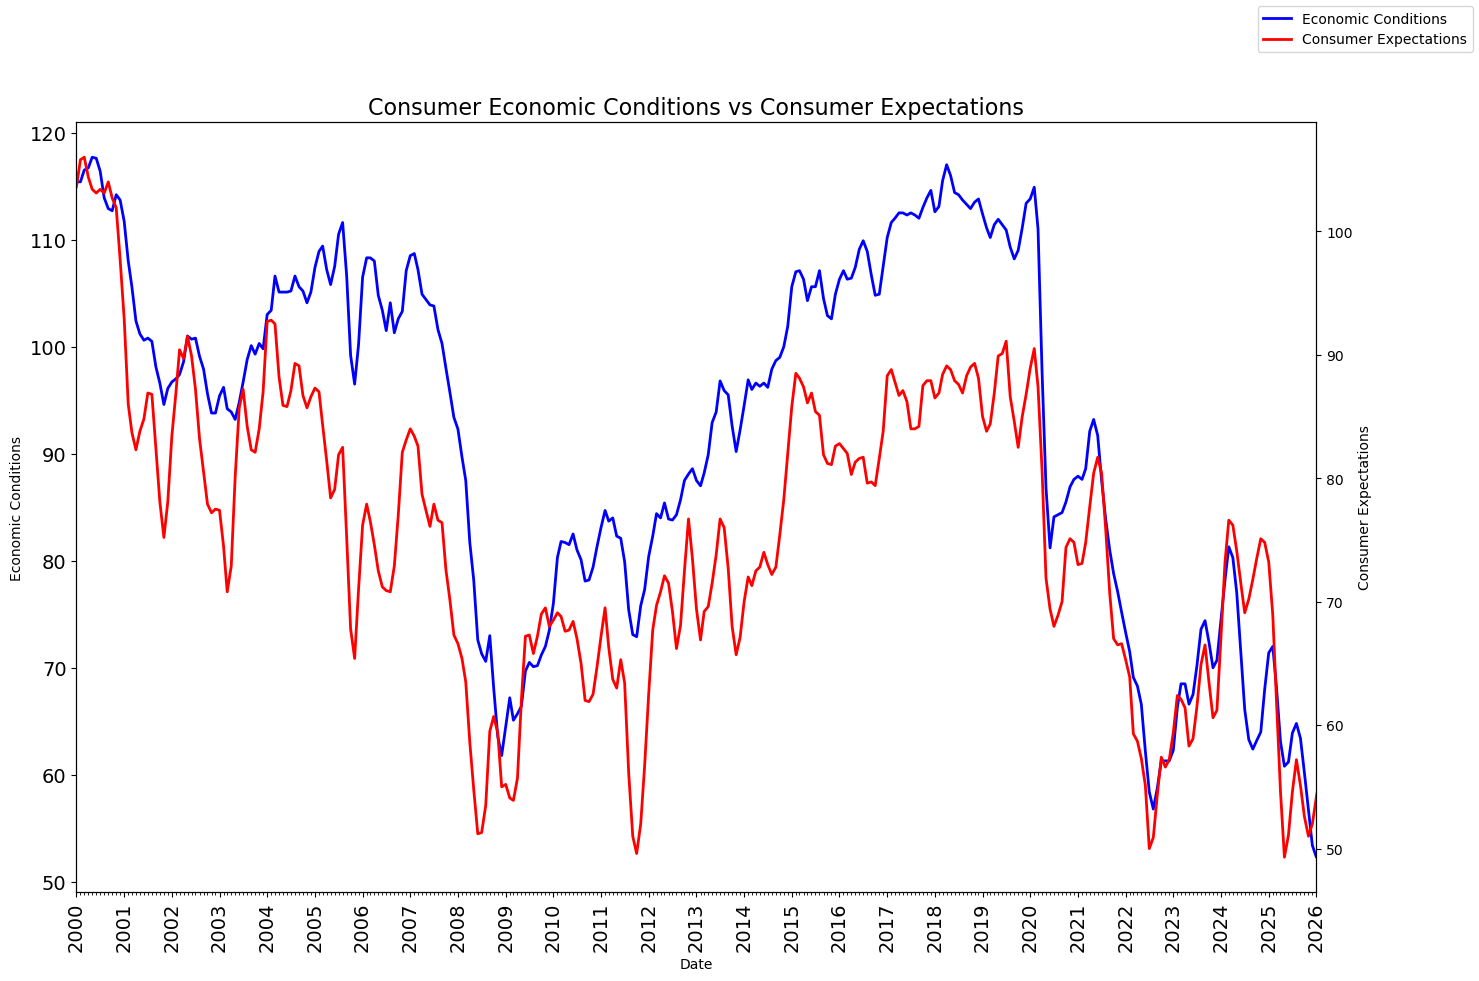

In [52]:
## Plot
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14, rotation = 90)
plt.yticks(fontsize=14)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(clean_df["Date"],
         clean_df["Economic_Conditions_index"],
         color="Blue",
         linewidth=2,
         label="Economic Conditions")
ax2.plot(clean_df["Date"],
         clean_df["Consumer_Expectations_index"],
         color="Red",
         linewidth=2,
         label="Consumer Expectations")

    ## Adding in the date functionalities
Year = mdates.YearLocator()
Months = mdates.MonthLocator()
Years_FMT = mdates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(Year)
ax1.xaxis.set_minor_locator(Months)
ax1.xaxis.set_major_formatter(Years_FMT)





ax1.set_xlabel("Date")
ax1.set_ylabel("Economic Conditions")
ax2.set_ylabel("Consumer Expectations")
plt.xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2026-01-01"))

plt.title("Consumer Economic Conditions vs Consumer Expectations", fontsize=16)
fig= plt.gcf()
fig.legend()
fig.show()